In [48]:
import pandas as pd
import numpy as np
pd.set_option({'display.max_rows':300,'display.max_columns':300})

csv_path = "data/backtest_score_predictions.csv"
df = pd.read_csv(csv_path)

for k in [1, 3, 8, 10]:
      sums = df.groupby('tournament_slug')[f'p_top{k}_given_play'].transform('sum')
      df[f'p_top{k}_renorm'] = df[f'p_top{k}_given_play'] * k / sums

      p_col = df[f'p_top{k}_renorm']
      in_col = df[f'in_top{k}']
      min_viable_bet = k/100

      df[f'p_top{k}_yes_performance'] = np.where(
            p_col > min_viable_bet,
            (1/p_col) * in_col,
            np.nan
      )
      df[f'p_top{k}_no_performance'] = np.where(
            p_col > min_viable_bet,
            (1/(1-p_col)) * (1-in_col),
            np.nan
      )

# df.to_csv(csv_path, index=False)


df[df['in_top8']==1].head(40)

,tournament_slug,date,username,rank,field_size,p_participate,p_top1,p_top1_given_play,in_top1,p_top3,p_top3_given_play,in_top3,p_top8,p_top8_given_play,in_top8,p_top10,p_top10_given_play,in_top10,p_top1_renorm,p_top1_yes_performance,p_top1_no_performance,p_top3_renorm,p_top3_yes_performance,p_top3_no_performance,p_top8_renorm,p_top8_yes_performance,p_top8_no_performance,p_top10_renorm,p_top10_yes_performance,p_top10_no_performance
0,early-titled-tuesday-blitz-february-08-2022-29...,2022-02-08,kirillshevchenko,1,485,0.1314,0.0044,0.033486,1,0.0070,0.053272,1,0.0184,0.140030,1,0.0264,0.200913,1,0.032276,30.982859,0.000000,0.045370,22.040985,0.000000,0.105524,9.476521,0.0,0.148178,6.748662,0.0
1,early-titled-tuesday-blitz-february-08-2022-29...,2022-02-08,Grandelicious,2,485,0.2408,0.0000,0.000000,0,0.0008,0.003322,1,0.0222,0.092193,1,0.0362,0.150332,1,0.000000,NaN,NaN,0.002829,NaN,NaN,0.069475,NaN,NaN,0.110873,9.019330,0.0
2,early-titled-tuesday-blitz-february-08-2022-29...,2022-02-08,GHANDEEVAM2003,3,485,0.3688,0.0000,0.000000,0,0.0000,0.000000,1,0.0030,0.008134,1,0.0056,0.015184,1,0.000000,NaN,NaN,0.000000,NaN,NaN,0.006130,NaN,NaN,0.011199,NaN,NaN
3,early-titled-tuesday-blitz-february-08-2022-29...,2022-02-08,VerdeNotte,4,485,0.5302,0.0000,0.000000,0,0.0010,0.001886,0,0.0442,0.083365,1,0.0752,0.141833,1,0.000000,NaN,NaN,0.001606,NaN,NaN,0.062822,NaN,NaN,0.104605,9.559791,0.0
4,early-titled-tuesday-blitz-february-08-2022-29...,2022-02-08,GMHess,5,485,0.4476,0.0002,0.000447,0,0.0026,0.005809,0,0.0154,0.034406,1,0.0216,0.048257,1,0.000431,NaN,NaN,0.004947,NaN,NaN,0.025928,NaN,NaN,0.035591,NaN,NaN
5,early-titled-tuesday-blitz-february-08-2022-29...,2022-02-08,BogdanDeac,6,485,0.6998,0.0050,0.007145,0,0.0412,0.058874,0,0.1830,0.261503,1,0.2358,0.336953,1,0.006887,NaN,NaN,0.050141,0.000000,1.052788,0.197064,5.074501,0.0,0.248510,4.023985,0.0
6,early-titled-tuesday-blitz-february-08-2022-29...,2022-02-08,Micki-taryan,7,485,0.1328,0.0020,0.015060,0,0.0084,0.063253,0,0.0268,0.201807,1,0.0362,0.272590,1,0.014516,0.000000,1.014730,0.053871,0.000000,1.056938,0.152078,6.575576,0.0,0.201041,4.974115,0.0
7,early-titled-tuesday-blitz-february-08-2022-29...,2022-02-08,FairChess_on_YouTube,8,485,0.8884,0.0712,0.080144,0,0.1572,0.176947,0,0.3576,0.402521,1,0.4340,0.488519,1,0.077248,0.000000,1.083715,0.150700,0.000000,1.177440,0.303332,3.296716,0.0,0.360293,2.775519,0.0
485,late-titled-tuesday-blitz-february-08-2022-294...,2022-02-08,lachesisQ,1,340,0.1912,0.0106,0.055439,1,0.0290,0.151674,1,0.0448,0.234310,1,0.0568,0.297071,1,0.058735,17.025560,0.000000,0.151535,6.599156,0.000000,0.218258,4.581744,0.0,0.277654,3.601608,0.0
486,late-titled-tuesday-blitz-february-08-2022-294...,2022-02-08,Sviridov_Valery,2,340,0.6736,0.0182,0.027019,0,0.0778,0.115499,1,0.3056,0.453682,1,0.3614,0.536520,1,0.028625,0.000000,1.029469,0.115393,8.666052,0.000000,0.422600,2.366301,0.0,0.501452,1.994210,0.0


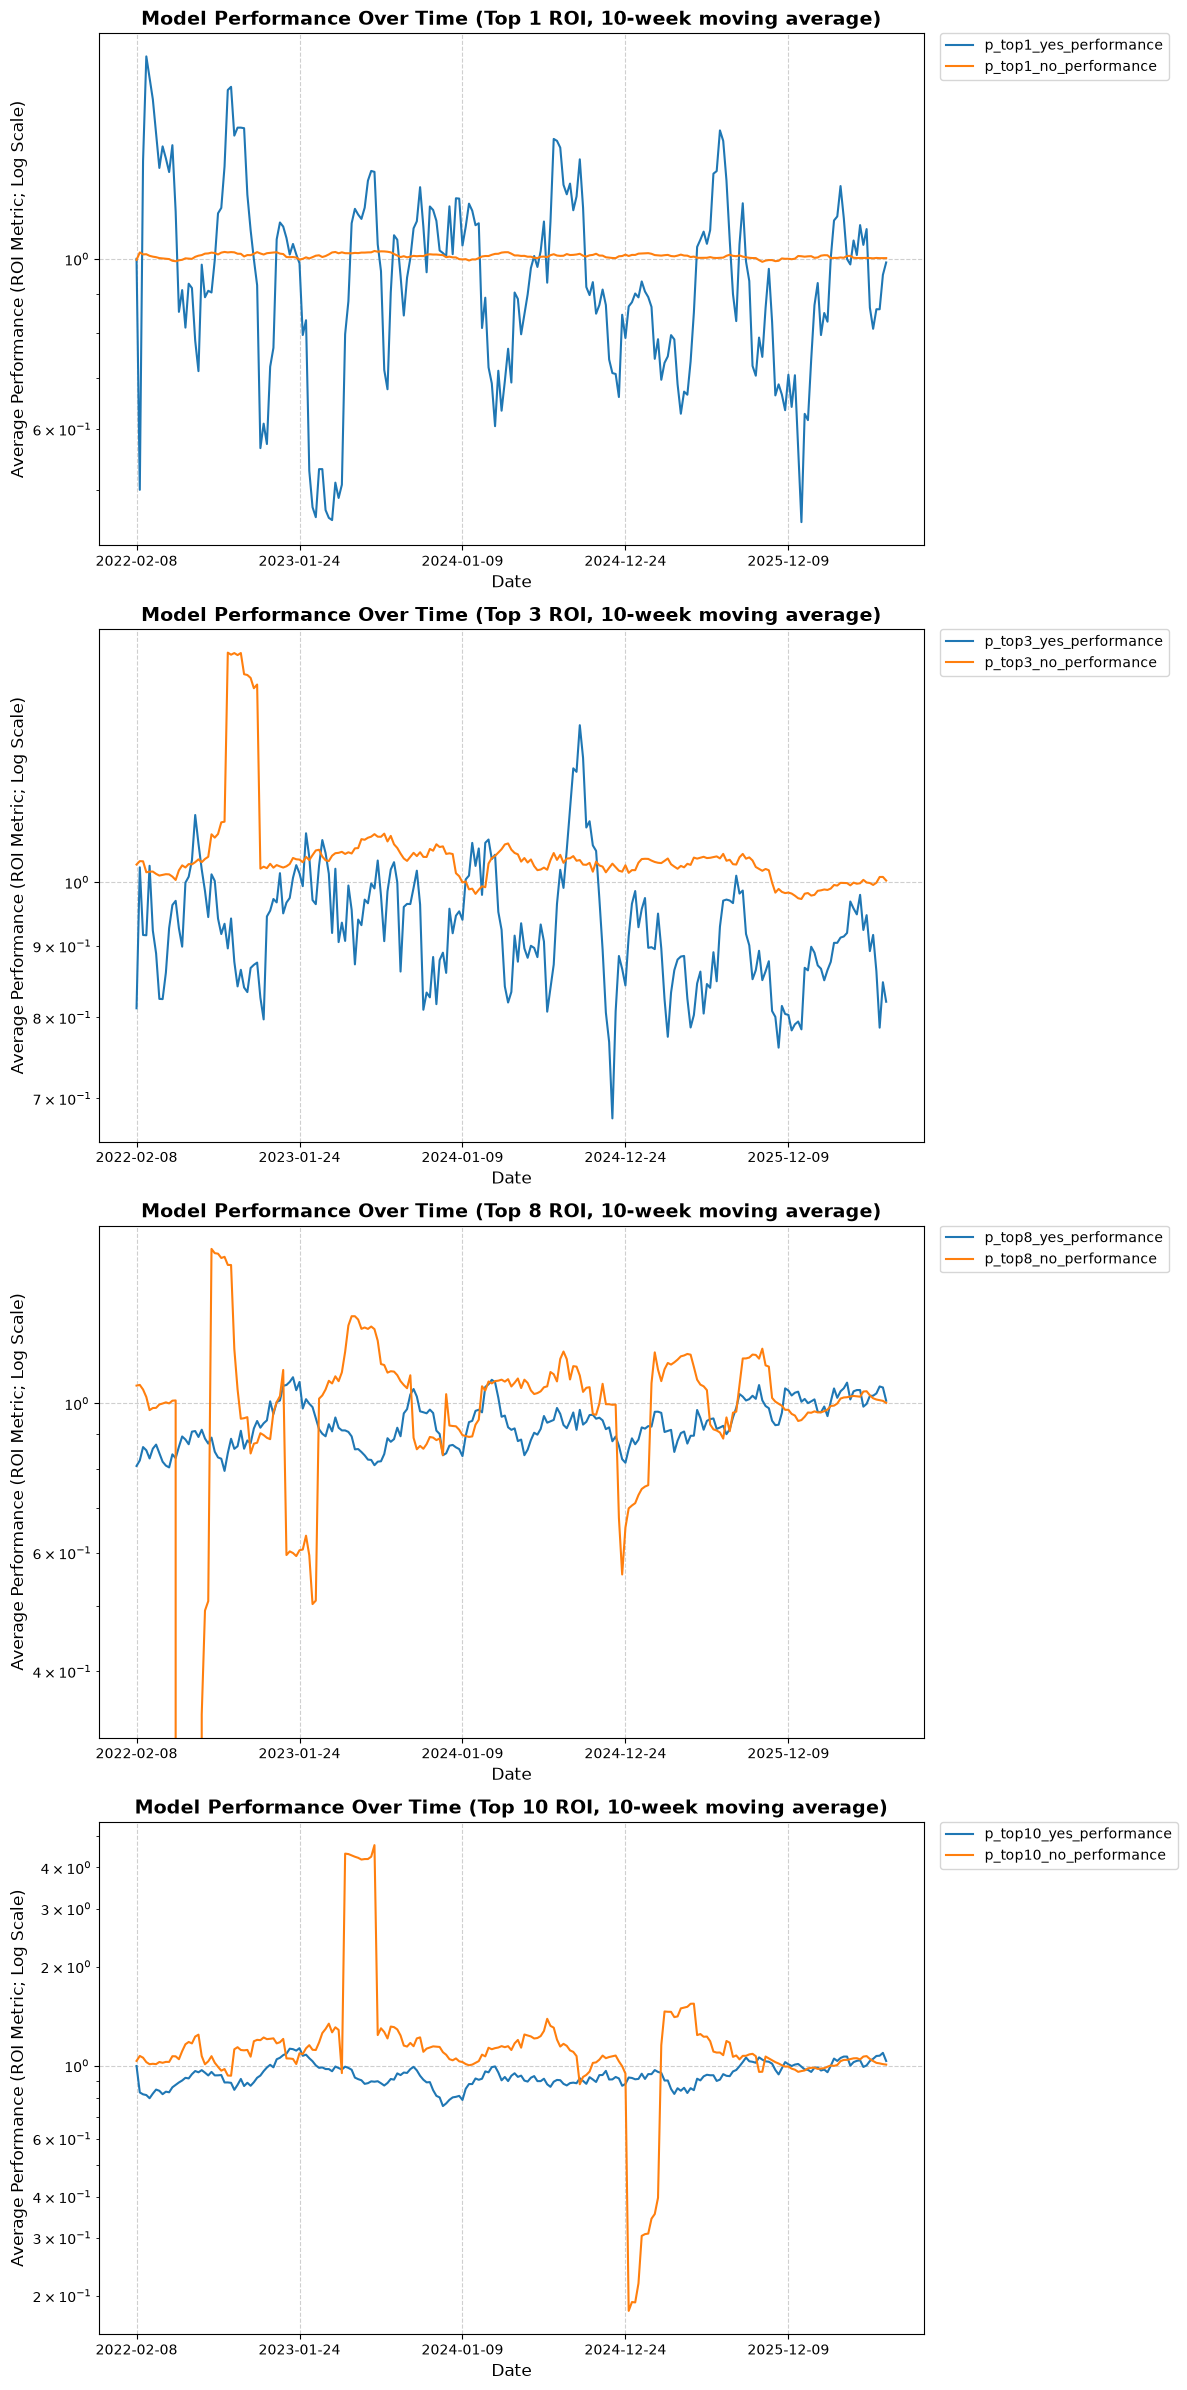

In [49]:
import matplotlib.pyplot as plt

# 1. Group by 'date' and compute the mean across all performance metrics
performance_cols = [f'p_top{k}_{yn}_performance' for k in [1, 3, 8, 10] for yn in ['yes', 'no']]
performance_over_time = df.groupby('date')[performance_cols].mean().sort_index()
performance_over_time = performance_over_time.sort_index()

# 2. Calculate the moving average
# Adjust 'window' to change the smoothing strength (e.g., 3, 5, 10)
smoothed_performance = performance_over_time.rolling(window=10, min_periods=1).mean()

# 2. Plot the aggregated metrics
fig, ax = plt.subplots(4, 1, figsize=(12, 24))

for i, k in enumerate([1, 3, 8, 10]):
    smoothed_performance[[f'p_top{k}_{yn}_performance' for yn in ['yes', 'no']]].plot(ax=ax[i], marker='')

    # 3. Format and clean up the chart presentation
    ax[i].set_yscale('log')
    ax[i].set_title(f'Model Performance Over Time (Top {k} ROI, 10-week moving average)', fontsize=14, fontweight='bold')
    ax[i].set_xlabel('Date', fontsize=12)
    ax[i].set_ylabel('Average Performance (ROI Metric; Log Scale)', fontsize=12)
    ax[i].grid(True, linestyle='--', alpha=0.6)

    # Place the legend cleanly outside the main plot area so lines aren't obscured
    ax[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.savefig('model_performance_over_time.png', dpi=300)

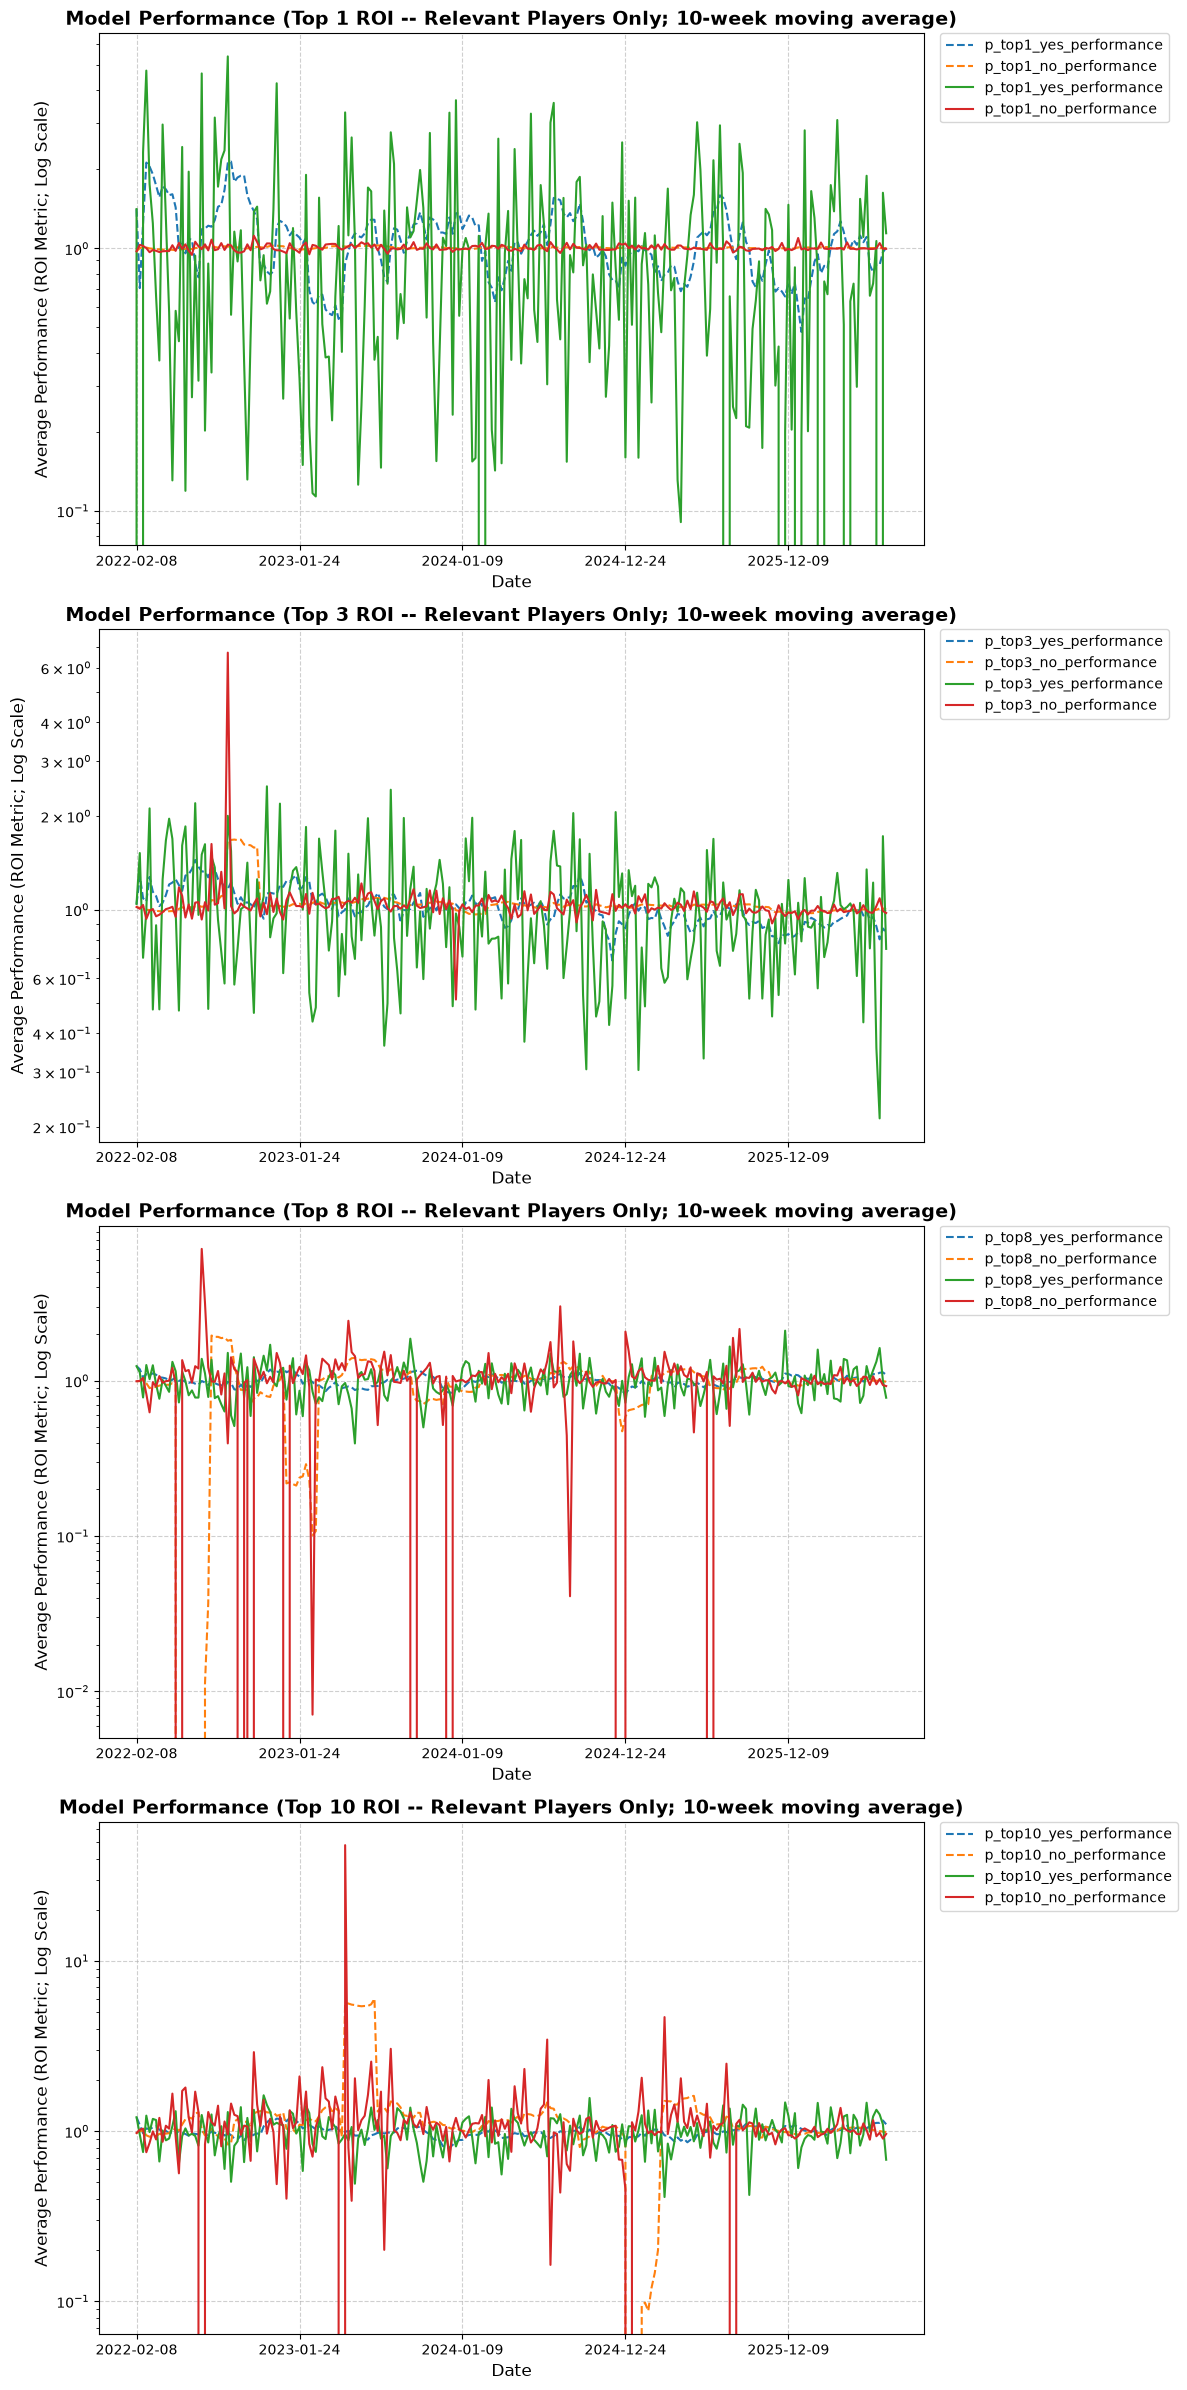

In [50]:
import matplotlib.pyplot as plt
from bootstrap_mc_kalshi import USERNAME_TO_PLAYER

df_kalshi = df[df['username'].isin(USERNAME_TO_PLAYER)]
df_kalshi.head()
# 1. Group by 'date' and compute the mean across all performance metrics
performance_cols = [f'p_top{k}_{yn}_performance' for k in [1, 3, 8, 10] for yn in ['yes', 'no']]
performance_over_time = df_kalshi.groupby('date')[performance_cols].mean().sort_index()
performance_over_time = performance_over_time.sort_index()

# 2. Calculate the moving average
# Adjust 'window' to change the smoothing strength (e.g., 3, 5, 10)
smoothed_performance = performance_over_time.rolling(window=10, min_periods=1).mean()

# 2. Plot the aggregated metrics
fig, ax = plt.subplots(4, 1, figsize=(12, 24))

for i, k in enumerate([1, 3, 8, 10]):
    smoothed_performance[[f'p_top{k}_{yn}_performance' for yn in ['yes', 'no']]].plot(ax=ax[i], linestyle='--')
    performance_over_time[[f'p_top{k}_{yn}_performance' for yn in ['yes', 'no']]].plot(ax=ax[i])

    # 3. Format and clean up the chart presentation
    ax[i].set_yscale('log')
    ax[i].set_title(f'Model Performance (Top {k} ROI -- Relevant Players Only; 10-week moving average)', fontsize=14, fontweight='bold')
    ax[i].set_xlabel('Date', fontsize=12)
    ax[i].set_ylabel('Average Performance (ROI Metric; Log Scale)', fontsize=12)
    ax[i].grid(True, linestyle='--', alpha=0.6)

    # Place the legend cleanly outside the main plot area so lines aren't obscured
    ax[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.savefig('model_performance_over_time.png', dpi=300)

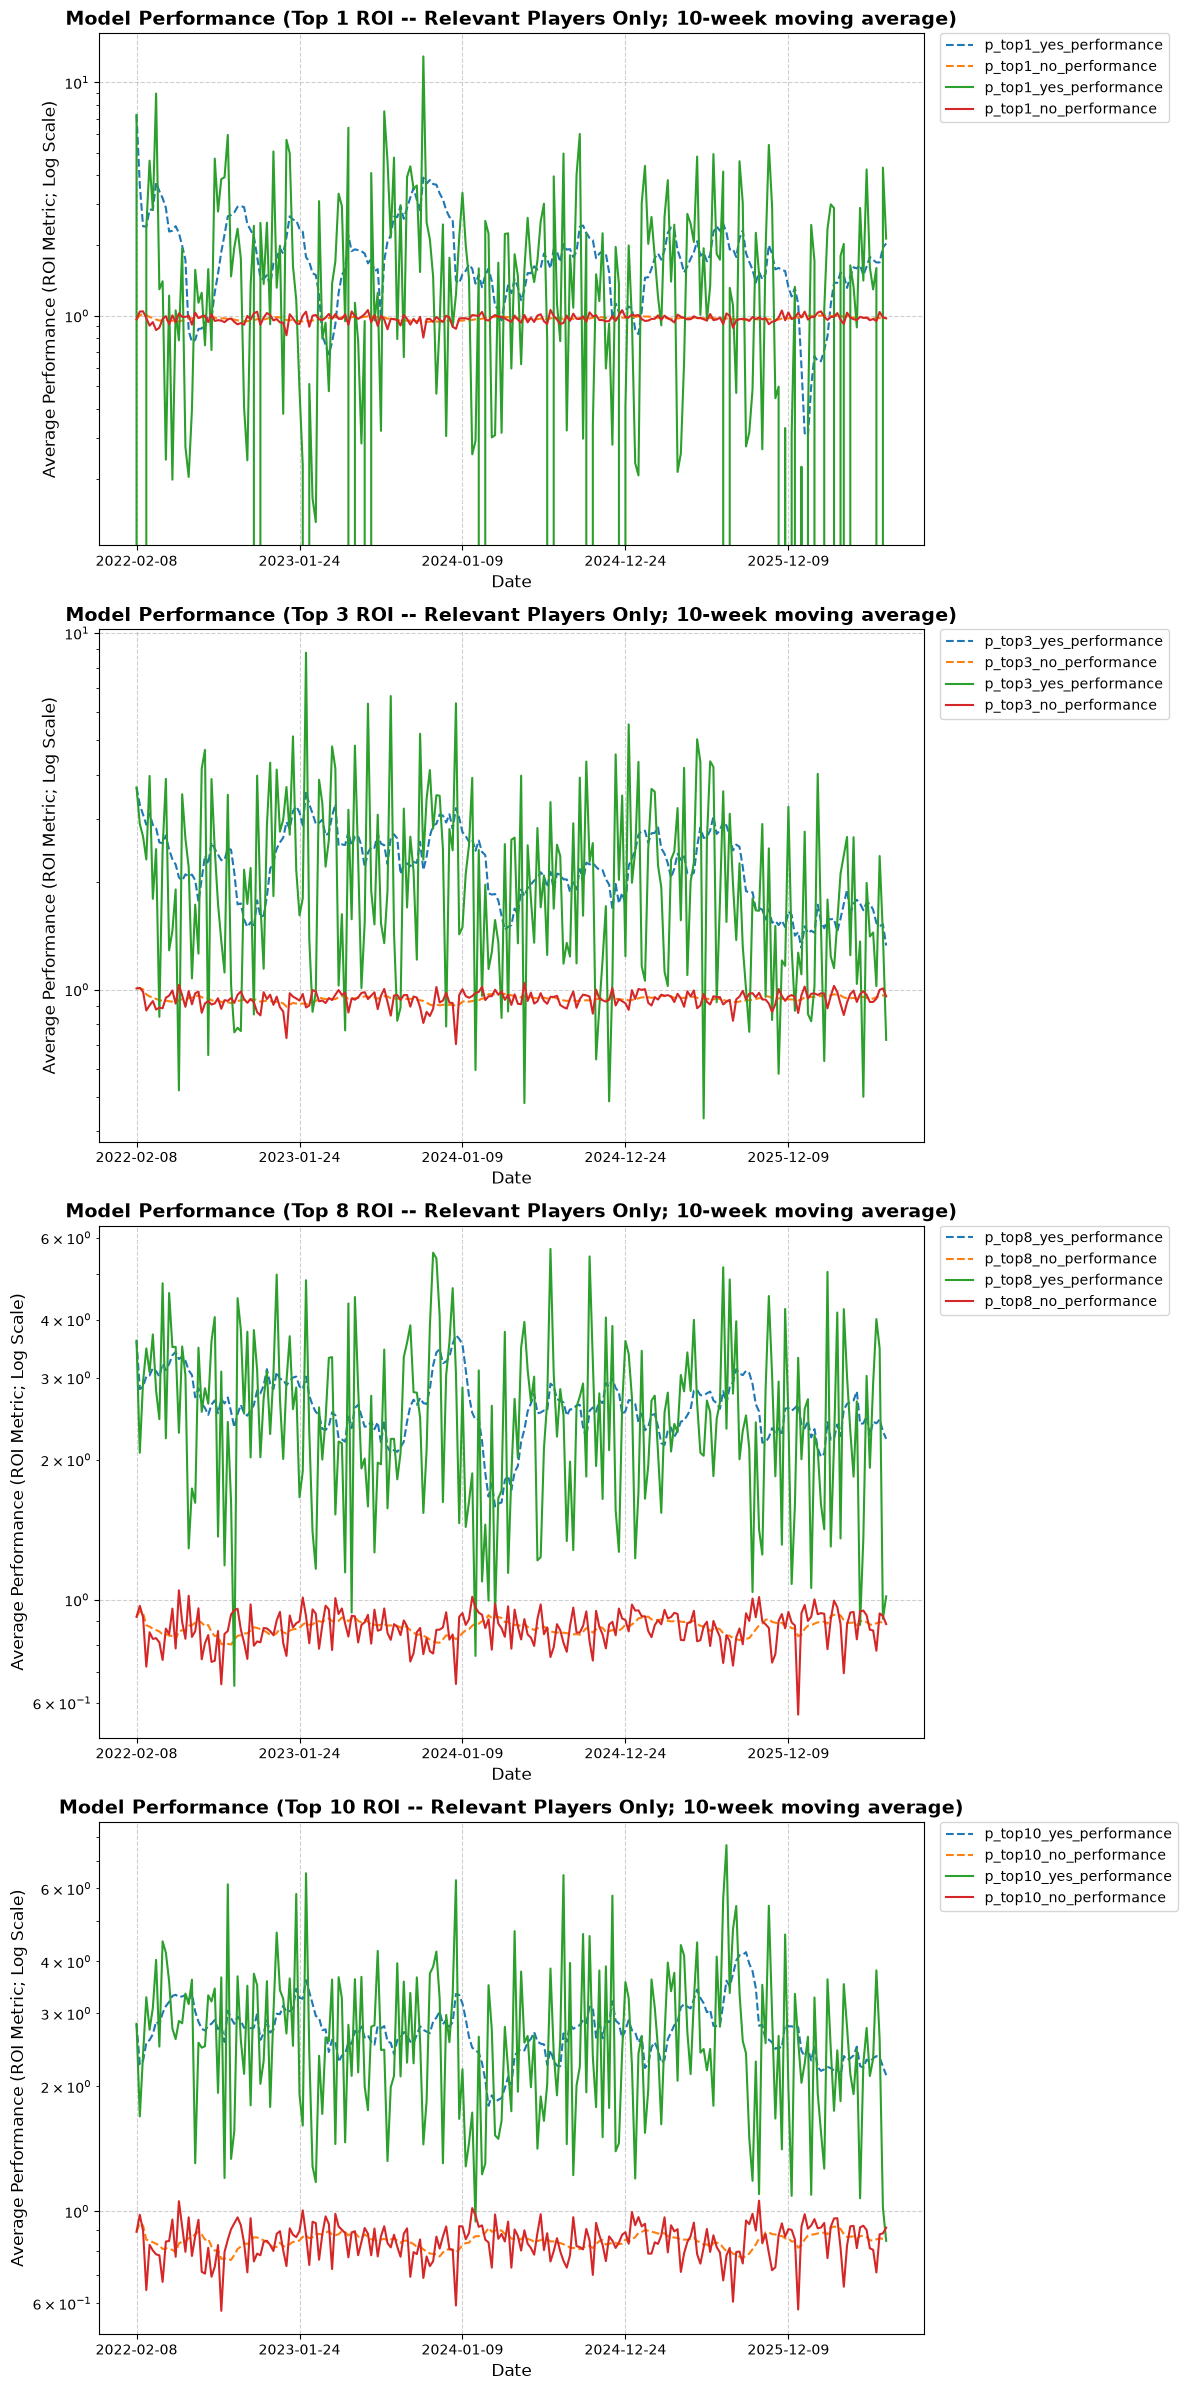

In [6]:
import matplotlib.pyplot as plt
from bootstrap_mc_kalshi import PLAYER_TO_USERNAMES

my_horses = [PLAYER_TO_USERNAMES[p][0] for p in [
    'Arjun Erigaisi',
    'Denis Lazavik',
    'Dmitry Andreikin',
    'Haik Martirosyan',
    'Jan-Krzysztof Duda',
    'Jeffery Xiong',
    'Le Tuan Minh',
    'Matthias Bluebaum',
    'Parham Maghsoodloo',
    'Renato Terry Lujan',
    'Sam Sevian',
    'Sina Movahed']]

df_kalshi = df[df['username'].isin(USERNAME_TO_PLAYER)]
df_kalshi.head()
# 1. Group by 'date' and compute the mean across all performance metrics
performance_cols = [f'p_top{k}_{yn}_performance' for k in [1, 3, 8, 10] for yn in ['yes', 'no']]
performance_over_time = df_kalshi.groupby('date')[performance_cols].mean().sort_index()
performance_over_time = performance_over_time.sort_index()

# 2. Calculate the moving average
# Adjust 'window' to change the smoothing strength (e.g., 3, 5, 10)
smoothed_performance = performance_over_time.rolling(window=10, min_periods=1).mean()

# 2. Plot the aggregated metrics
fig, ax = plt.subplots(4, 1, figsize=(12, 24))

for i, k in enumerate([1, 3, 8, 10]):
    smoothed_performance[[f'p_top{k}_{yn}_performance' for yn in ['yes', 'no']]].plot(ax=ax[i], linestyle='--')
    performance_over_time[[f'p_top{k}_{yn}_performance' for yn in ['yes', 'no']]].plot(ax=ax[i])

    # 3. Format and clean up the chart presentation
    ax[i].set_yscale('log')
    ax[i].set_title(f'Model Performance (Top {k} ROI -- Relevant Players Only; 10-week moving average)', fontsize=14, fontweight='bold')
    ax[i].set_xlabel('Date', fontsize=12)
    ax[i].set_ylabel('Average Performance (ROI Metric; Log Scale)', fontsize=12)
    ax[i].grid(True, linestyle='--', alpha=0.6)

    # Place the legend cleanly outside the main plot area so lines aren't obscured
    ax[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.savefig('model_performance_over_time.png', dpi=300)

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from bootstrap_mc_kalshi import USERNAME_TO_PLAYER
import matplotlib.colors as mcolors
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')

df_kalshi = df[df['username'].isin(USERNAME_TO_PLAYER)]
df_kalshi['name'] = df_kalshi['username'].apply(lambda text: USERNAME_TO_PLAYER[text])

# 1. Group by 'player' and compute the mean across all performance metrics
performance_cols = [f'p_top{k}_{yn}_performance' for k in [1, 3, 8, 10] for yn in ['yes', 'no']]
performance_by_player = df_kalshi.groupby('name')[performance_cols].agg([np.sum, 'mean'])
performance_by_player

p_top1_yes_performance            \
                                                   sum      mean   
name                                                               
Aleksandar Indjic                             0.000000  0.000000   
Aleksandr Shimanov                            0.000000       NaN   
Aleksandr Usov                                0.000000       NaN   
Aleksei Sarana                              585.498510  1.785056   
Alexander Grischuk                          115.547079  1.481373   
Alexander Moskalenko                          0.000000       NaN   
Alireza Firouzja                            406.950017  2.164628   
Almas Rakhmatullaev                           0.000000       NaN   
Andrew Tang                                   0.000000       NaN   
Andrey Esipenko                               0.000000  0.000000   
Anish Giri                                    0.000000  0.000000   
Anton Demchenko                               0.000000       NaN   
Anton Korobov                                 0.000000  0.000000   
Aravindh Chithambaram                         0.000000       NaN   
Arjun Erigaisi                               77.724836  0.883237   
Aryan Tari                                    0.000000  0.000000   
Baadur Jobava                               138.170653  1.818035   
Bardiya Daneshvar                             0.000000       NaN   
Benjamin Bok                                  0.000000  0.000000   
Bogdan-Daniel Deac                           69.444444  1.157407   
Christopher Yoo                              86.206897  1.874063   
Conrad Holt                                   0.000000  0.000000   
Cristobal Henriquez Villagra                  0.000000       NaN   
Daniel Naroditsky                             0.000000  0.000000   
Daniil Dubov                                445.468041  3.775153   
Dariusz Swiercz                               0.000000  0.000000   
Dau Khuong Duy                                0.000000  0.000000   
David Paravyan                                0.000000  0.000000   
De La Garza, Miguel                           0.000000       NaN   
Denis Lazavik                               402.191851  2.935707   
Dincer Tasdogen                               0.000000       NaN   
Dmitrij Kollars                               0.000000  0.000000   
Dmitrij Osetrov                               0.000000       NaN   
Dmitry Andreikin                            445.909275  1.433792   
Eduardo Iturrizaga Bonelli                   33.783784  5.630631   
Elshan Moradiabadi                            0.000000       NaN   
Eltaj Safarli                                 0.000000  0.000000   
Fabiano Caruana                              40.983607  0.435996   
Faustino Oro                                  0.000000       NaN   
Francisco Vallejo Pons                        0.000000       NaN   
Frederik Svane                                0.000000       NaN   
Gadir Guseinov                                0.000000  0.000000   
Georg Meier                                   0.000000       NaN   
Giga Quparadze                                0.000000       NaN   
Grigoriy Oparin                               0.000000  0.000000   
Haik Martirosyan                              0.000000  0.000000   
Hans Niemann                                213.701436  2.374460   
Haowen Xue                                    0.000000  0.000000   
Hardy Gu                                      0.000000       NaN   
Hikaru Nakamura                             416.173765  1.317006   
Ian Nepomniachtchi                          387.577341  5.458836   
Jan-Krzysztof Duda                          428.107373  2.339385   
Javokhir Sindarov                           171.091186  4.073600   
Jeffery Xiong                               228.999351  1.036196   
Joaquin Castro Castro                         0.000000       NaN   
Jose Carlos Ibarra Jerez                      0.000000       NaN   
Jose Martinez       

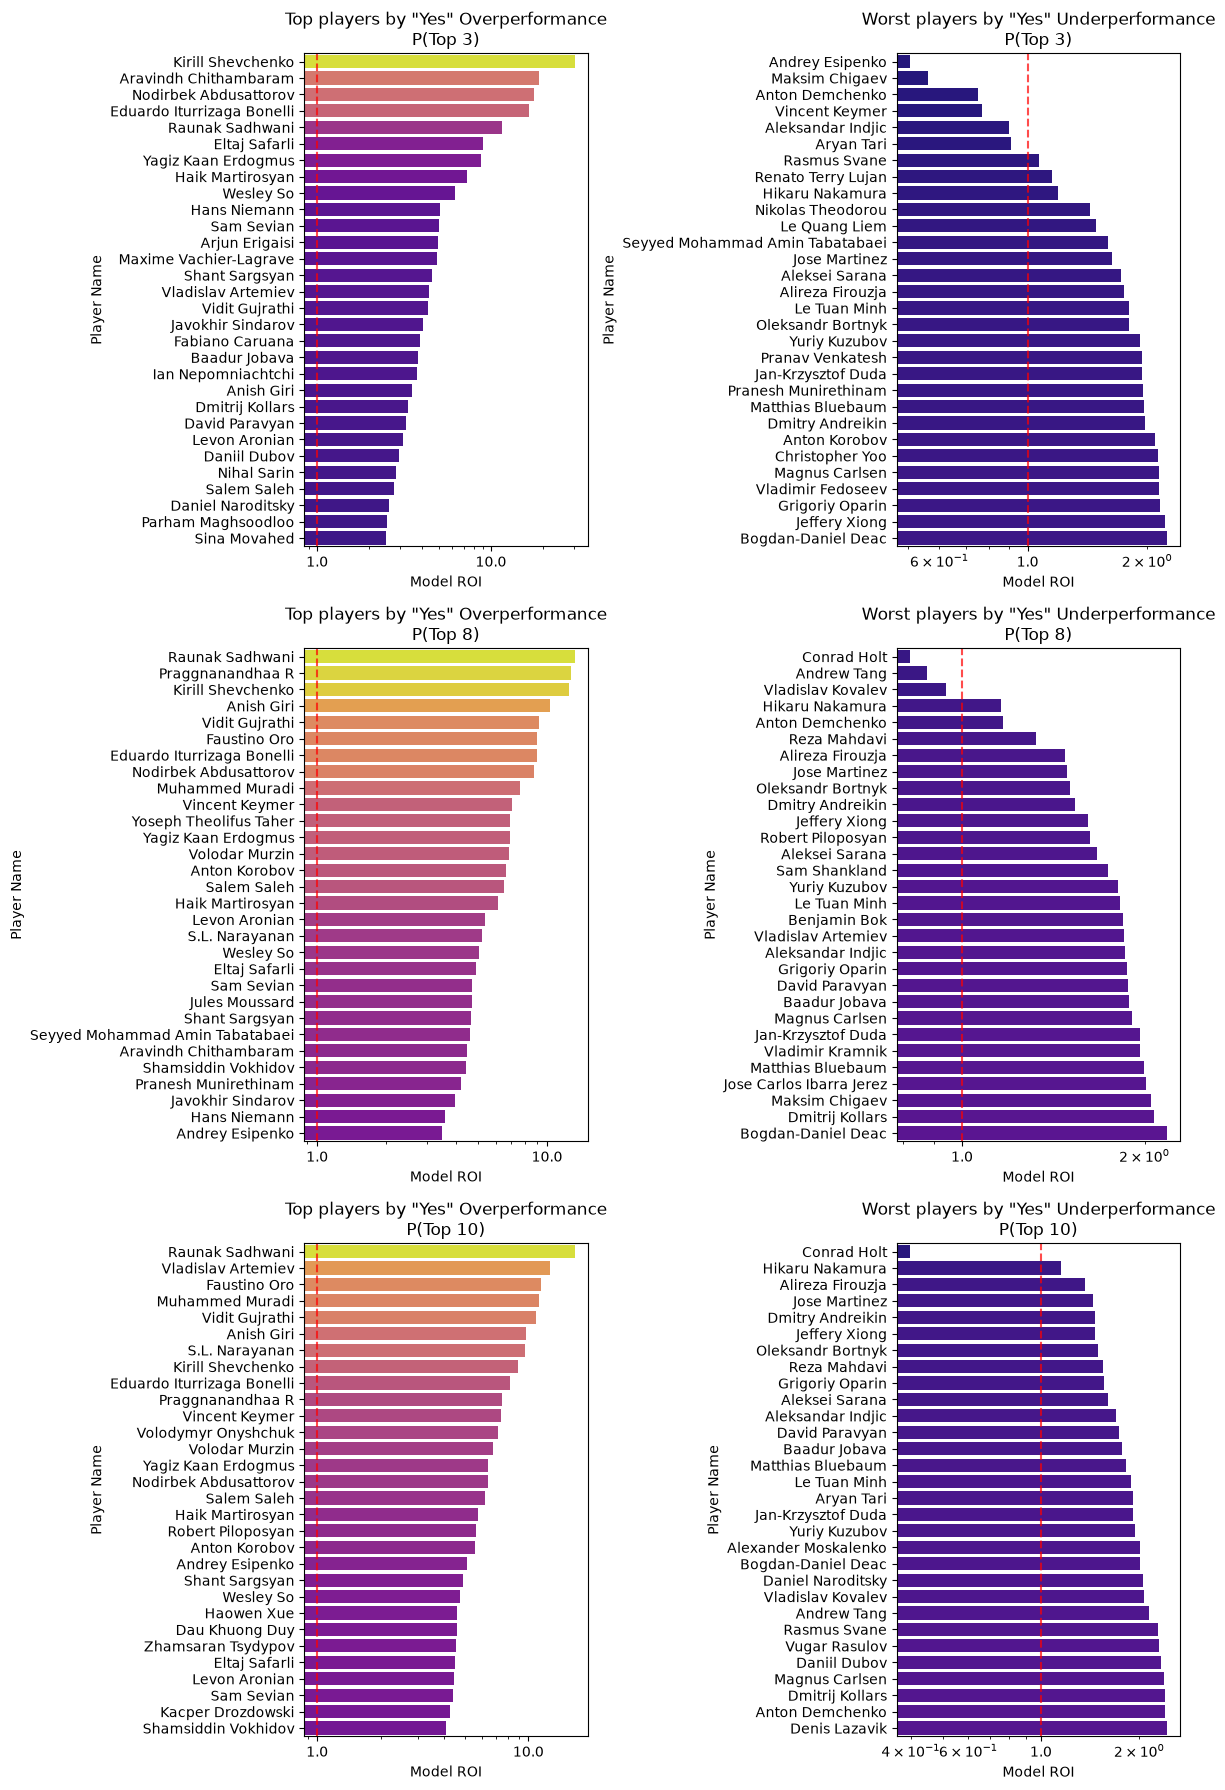

In [59]:
import matplotlib.ticker as ticker

cmap = plt.get_cmap('plasma')

formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)

# 1. Changed rows from 4 to 3 since you are looping through 3 values [3, 8, 10]
fig, ax = plt.subplots(3, 2, figsize=(12, 18)) 

for i, k in enumerate([3, 8, 10]):

    col_perf = f'p_top{k}_yes_performance'
    
    # Define the exact tuple keys for the MultiIndex
    sum_col = (col_perf, 'sum')
    mean_col = (col_perf, 'mean')
    # 2. Filter by 'sum' > 10, then get nlargest based on the 'mean' sub-column
    df_over = performance_by_player[performance_by_player[sum_col] > 10].nlargest(30, mean_col)
    df_under = performance_by_player[performance_by_player[sum_col] > 10].nsmallest(30, mean_col)
    # 3. Normalize colors using the 'mean' data
    norm = mcolors.Normalize(vmin=performance_by_player[mean_col].min(), vmax=performance_by_player[mean_col].max())
    
    colors_over = cmap(norm(df_over[mean_col]))
    colors_under = cmap(norm(df_under[mean_col]))

    # 4. Pass the mean tuple to x, and use the player names (index) for y
    sns.barplot(
        data=df_over, 
        x=mean_col, 
        y=df_over.index,  # After groupby('name'), 'name' is now your index!
        ax=ax[i, 0], 
        palette=colors_over,
        orient='h'
    )
    sns.barplot(
        data=df_under, 
        x=mean_col, 
        y=df_under.index,  # After groupby('name'), 'name' is now your index!
        ax=ax[i, 1], 
        palette=colors_under,
        orient='h'
    )

    formatter = ticker.ScalarFormatter()
    formatter.set_scientific(False)  # Turn off scientific notation
    formatter.set_powerlimits((-2, 4))

    # Clean up the X-axis label so it doesn't show the ugly tuple text
    ax[i, 0].set_xlabel("Model ROI")
    ax[i, 0].set_ylabel("Player Name")
    ax[i,0].set_xscale('log')
    ax[i, 0].xaxis.set_major_formatter(formatter)
    ax[i, 0].set_title(f"Top players by \"Yes\" Overperformance\nP(Top {k})")
    
    # Clean up the X-axis label so it doesn't show the ugly tuple text
    ax[i, 1].set_xlabel("Model ROI")
    ax[i, 1].set_ylabel("Player Name")
    ax[i,1].set_xscale('log')
    ax[i, 1].xaxis.set_major_formatter(formatter)
    ax[i, 1].set_title(f"Worst players by \"Yes\" Underperformance\nP(Top {k})")

    # Add a dashed line at x=1 on the overperformance subplot
    ax[i, 0].axvline(x=1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

    # Add a dashed line at x=1 on the underperformance subplot
    ax[i, 1].axvline(x=1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.show()

In [63]:
dfp = df.groupby('username')['p_participate'].agg(['mean','sum'])
dfp[dfp['sum']>10].nsmallest(50,'mean')

,mean,sum
username,,
sonicdravise,0.214481,11.1530
grunbergmihai,0.223283,10.2710
korkmaz16,0.233691,10.7498
VitaliyBernadskiy,0.234653,10.5594
Darius321,0.235023,10.3410
kamilianin235,0.236844,13.9738
forevery0ung,0.237427,12.1088
Mbneu,0.237452,10.9228
c63_amg,0.237736,11.8868
